<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
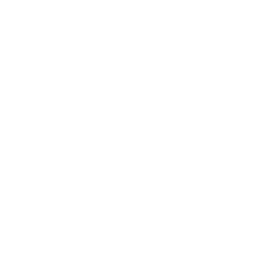
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Quality Metric Dimensionality Reduction</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufacturing / Process Control &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

An automotive parts line records 12 inspection metrics per part — four dimensional gauges, four surface-quality measures, and four material-strength tests. Because the gauges within each group move together, the 12 raw metrics carry far less than 12 dimensions of information. This notebook uses **PROC FACTOR** (principal-axis extraction with squared multiple correlations as prior communalities, `PRIORS=SMC`) to compress the 12 metrics into a small set of orthogonal factors suitable for multivariate process monitoring.

On the 100 inspected parts available in this environment, the overall Kaiser-Meyer-Olkin measure of sampling adequacy is **0.85**, and three factors reproduce **91.3%** of the variance with a sharp scree break after the third — cleanly recovering the dimensional, strength, and surface groupings. The retained factor scores are then passed to **PROC CLUSTER** (Ward's method) to look for part-level groupings in the reduced space.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.QUALITY_METRICS | 12 inspection measurements plus shift/line/operator metadata, one row per part | 100 |

The data are generated synthetically from three independent latent dimensions (dimensional accuracy, surface quality, material strength) so the factor structure is known in advance and the recovered solution can be checked against ground truth. This environment caps output at 100 observations, so the `DO` loop produces 500 parts but the analysis runs on the first 100.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic quality inspection measurements
   12 metrics from 3 INDEPENDENT latent dimensions;
   first 100 of 500 parts are analysed (output cap)
   -------------------------------------------------------- */
data work.quality_metrics;
    call streaminit(42);
    array shifts[3] $10 _temporary_ ('DAY' 'SWING' 'NIGHT');
    array lines[4] $6 _temporary_ ('LINE1' 'LINE2' 'LINE3' 'LINE4');
    do part_id = 1 to 500;
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shifts[shift_idx];
        line_idx = int(rand('uniform') * 4) + 1;
        prod_line = lines[line_idx];
        operator_id = cat('OP-', put(int(rand('uniform') * 30) + 1, z3.));
        inspection_date = '01JAN2026'd + int(rand('uniform') * 60);

        /* --- Dimensional accuracy factor --- */
        dim_base = rand('normal', 0, 1);
        length_mm      = round(150.0 + 0.5 * dim_base + rand('normal', 0, 0.12), 0.001);
        width_mm       = round(75.0 + 0.3 * dim_base + rand('normal', 0, 0.08), 0.001);
        thickness_mm   = round(12.0 + 0.15 * dim_base + rand('normal', 0, 0.04), 0.001);
        bore_diameter   = round(25.0 + 0.2 * dim_base + rand('normal', 0, 0.05), 0.001);

        /* --- Surface quality factor --- */
        surf_base = rand('normal', 0, 1);
        surface_roughness = round(max(0.1, 1.6 + 0.4 * surf_base + rand('normal', 0, 0.15)), 0.001);
        coating_thickness = round(max(0.5, 8.0 + 0.8 * surf_base + rand('normal', 0, 0.3)), 0.001);
        gloss_index       = round(max(10, 85 - 5 * surf_base + rand('normal', 0, 2)), 0.1);
        defect_count      = max(0, round(2 + 1.5 * surf_base + rand('normal', 0, 0.8)));

        /* --- Material strength factor --- */
        str_base = rand('normal', 0, 1);
        tensile_strength  = round(max(200, 450 + 30 * str_base + rand('normal', 0, 10)), 0.1);
        hardness_hrc      = round(max(20, 58 + 4 * str_base + rand('normal', 0, 1.5)), 0.1);
        yield_point       = round(max(150, 380 + 25 * str_base + rand('normal', 0, 8)), 0.1);
        elongation_pct    = round(max(1, 12 + 2 * str_base + rand('normal', 0, 1)), 0.1);

        output;
    end;
    drop dim_base surf_base str_base shift_idx line_idx;
    format inspection_date date9.;
run;

NOTE: DATA work.quality_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.quality_metrics (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

   Pearson Correlation Coefficients, N = 100
          Prob > |r| under H0: Rho=0
           length_mm  width_mmthickness_mmbore_diametersurface_roughnesscoating_thicknessgloss_indexdefect_counttensile_strengthhardness_hrcyield_pointelongation_pct
--------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------  --------
length_mm   1.00000   0.95387   0.94610   0.94834  -0.02280   0.05592  -0.00322   0.01776   0.00316  -0.00637   0.01689   0.00974
              .       <.0001    <.0001    <.0001    0.8218    0.5805    0.9746    0.8608    0.9751    0.9499    0.8676    0.9234
width_mm   0.95387   1.00000   0.94796   0.94784  -0.07471  -0.01371   0.06755  -0.05251   0.00931   0.00957   0.02390   0.03043
            <.0001      .       <.0001    <.0001    0.4601    0.8923    0.5043    0.6038    0.9267    0.9247    0.8134    0.7638
thickness_mm   0.94610   0.94796   1.00000   0.94054  -0.06727   0.01705   0.05266  -0.06345  -0.01870  -0

NOTE: PROC CORR data=work.quality_metrics

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


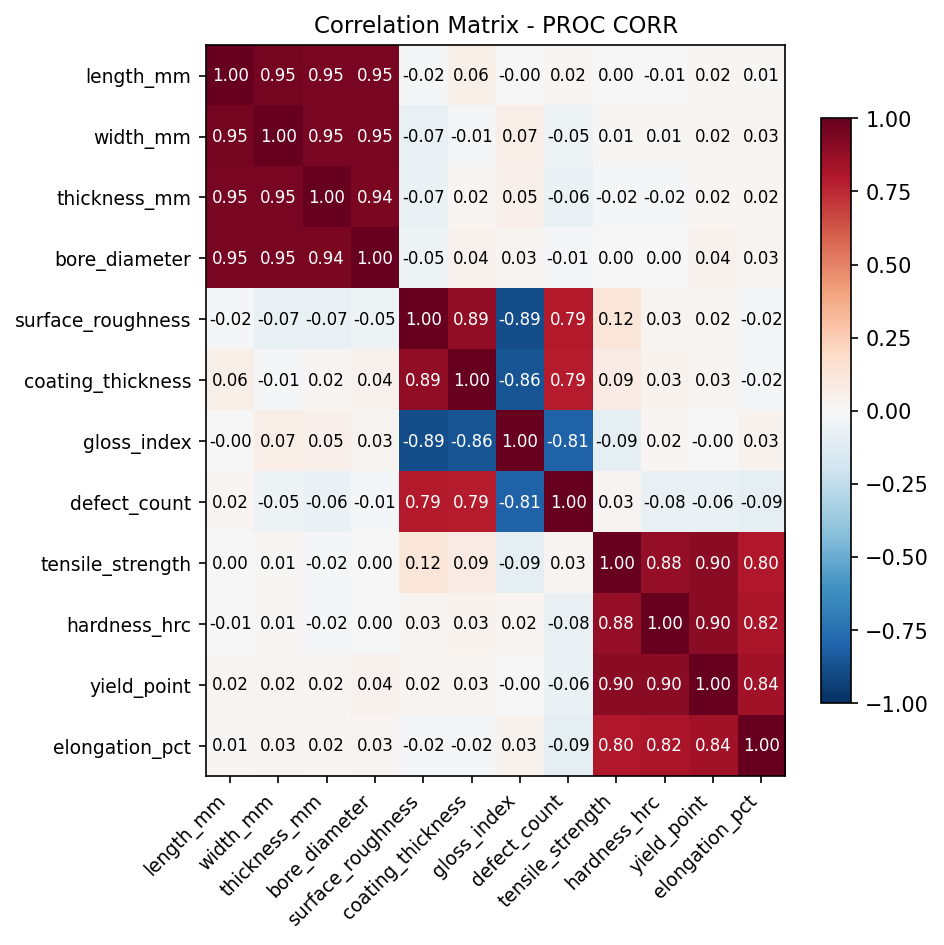

In [2]:
/* --------------------------------------------------------
   Correlation matrix to verify multicollinearity
   -------------------------------------------------------- */
proc corr data=work.quality_metrics nosimple;
    var length_mm width_mm thickness_mm bore_diameter
        surface_roughness coating_thickness gloss_index defect_count
        tensile_strength hardness_hrc yield_point elongation_pct;
run;

---


Eigenvalues of the Correlation Matrix
             Eigenvalue   Difference   Proportion   Cumulative
  Factor 1       3.8756       0.2774       0.3230       0.3230
  Factor 2       3.5982       0.1163       0.2998       0.6228
  Factor 3       3.4818       3.2319       0.2902       0.9130
  Factor 4       0.2499       0.0356       0.0208       0.9338
  Factor 5       0.2143       0.0605       0.0179       0.9516
  Factor 6       0.1539       0.0406       0.0128       0.9645
  Factor 7       0.1133       0.0175       0.0094       0.9739
  Factor 8       0.0958       0.0179       0.0080       0.9819
  Factor 9       0.0779       0.0223       0.0065       0.9884
 Factor 10       0.0557       0.0120       0.0046       0.9930
 Factor 11       0.0436       0.0035       0.0036       0.9967
 Factor 12       0.0401       0.0000       0.0033       1.0000

Factor Pattern
                Factor1    Factor2    Factor3
LENGTH_MM       -0.9820     0.0003    -0.0274
WIDTH_MM        -0.9812     0.0141

NOTE: PROC FACTOR data=work.quality_metrics

NOTE: Using Python numpy version 2.4.4
NOTE: ODS plot written: factor_scree.spec.json
NOTE: PROC FACTOR completed.


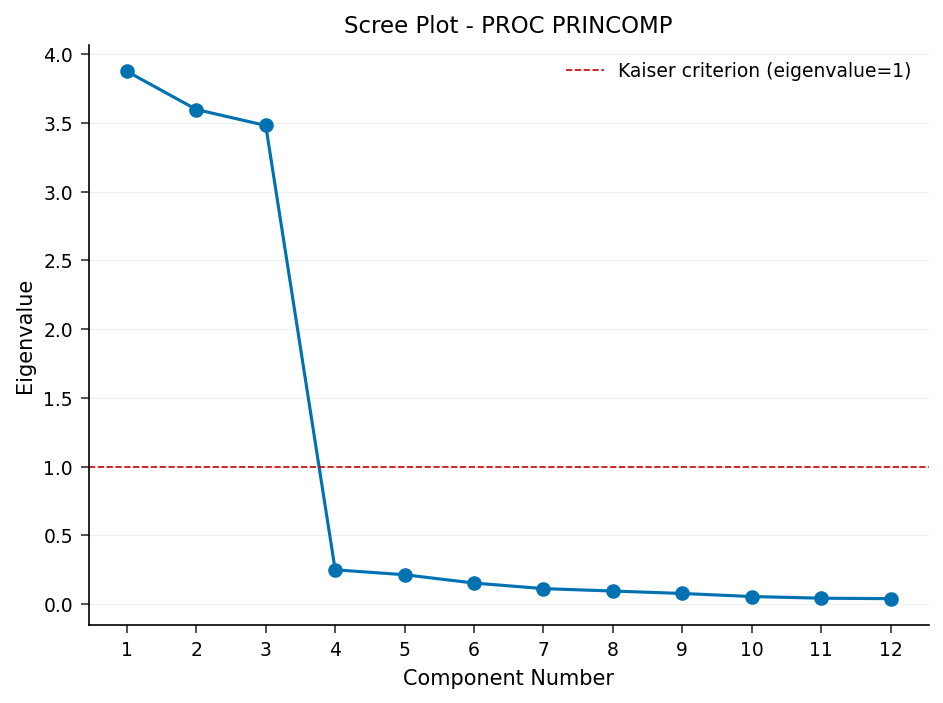

In [3]:
/* --------------------------------------------------------
   MSA test to verify sampling adequacy
   PRIORS=SMC for communality estimation
   Principal axis factoring with VARIMAX rotation
   -------------------------------------------------------- */
proc factor data=work.quality_metrics
    method=principal
    priors=smc
    nfactors=3
    rotate=varimax
    msa
    flag=0.4
    reorder
    out=work.quality_factors;
    var length_mm width_mm thickness_mm bore_diameter
        surface_roughness coating_thickness gloss_index defect_count
        tensile_strength hardness_hrc yield_point elongation_pct;
run;

---

NOTE: PROC SGPLOT data=work.quality_factors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


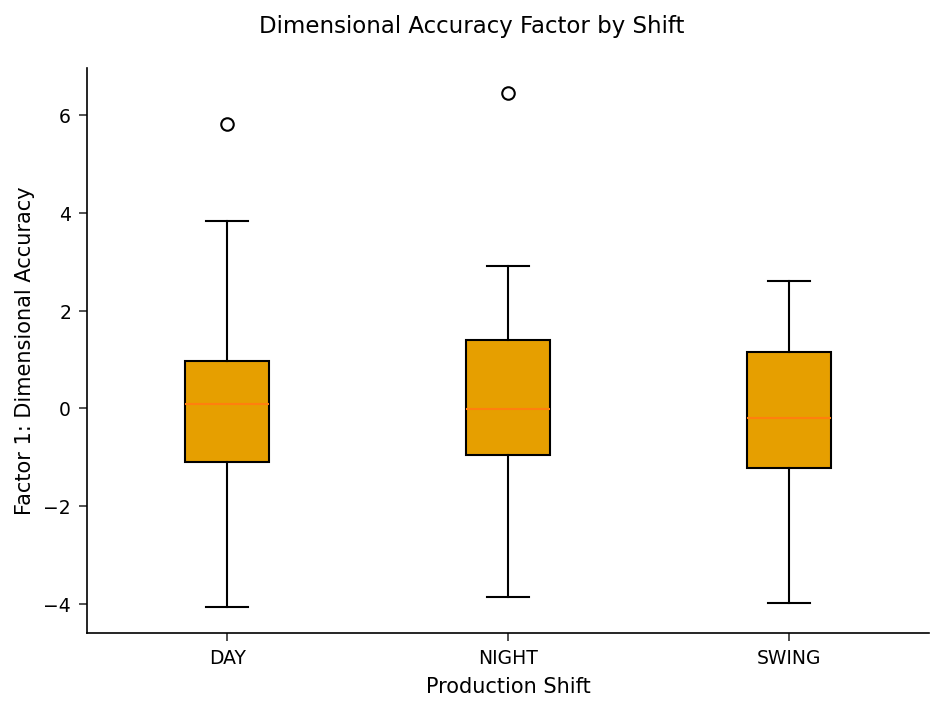

In [4]:
/* --------------------------------------------------------
   Factor 1 (dimensional accuracy) score by shift
   -------------------------------------------------------- */
proc sgplot data=work.quality_factors;
    vbox factor1 / category=shift;
    yaxis label='Factor 1: Dimensional Accuracy';
    xaxis label='Production Shift';
    title 'Dimensional Accuracy Factor by Shift';
run;

                                                 The CLUSTER Procedure
                                        Ward's Minimum Variance Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    51                81              2    0.0000    1.0000        0.3
    98    88                98              2    0.0000    0.9999        0.3
    97    76                85              2    0.0000    0.9999        0.3
    96    82                91              2    0.0001    0.9998        0.3
    95    18                20              2    0.0001    0.9997        0.4
    94    4                 23              2    0.0001    0.9996        0.5
    93    25                30              2    0.0001    0.9995        0.5
    92    8                 39              2    0.0001    0.9994        0.5
 

NOTE: PROC CLUSTER data=work.quality_factors method=Ward

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 3 variables clustered using Ward method


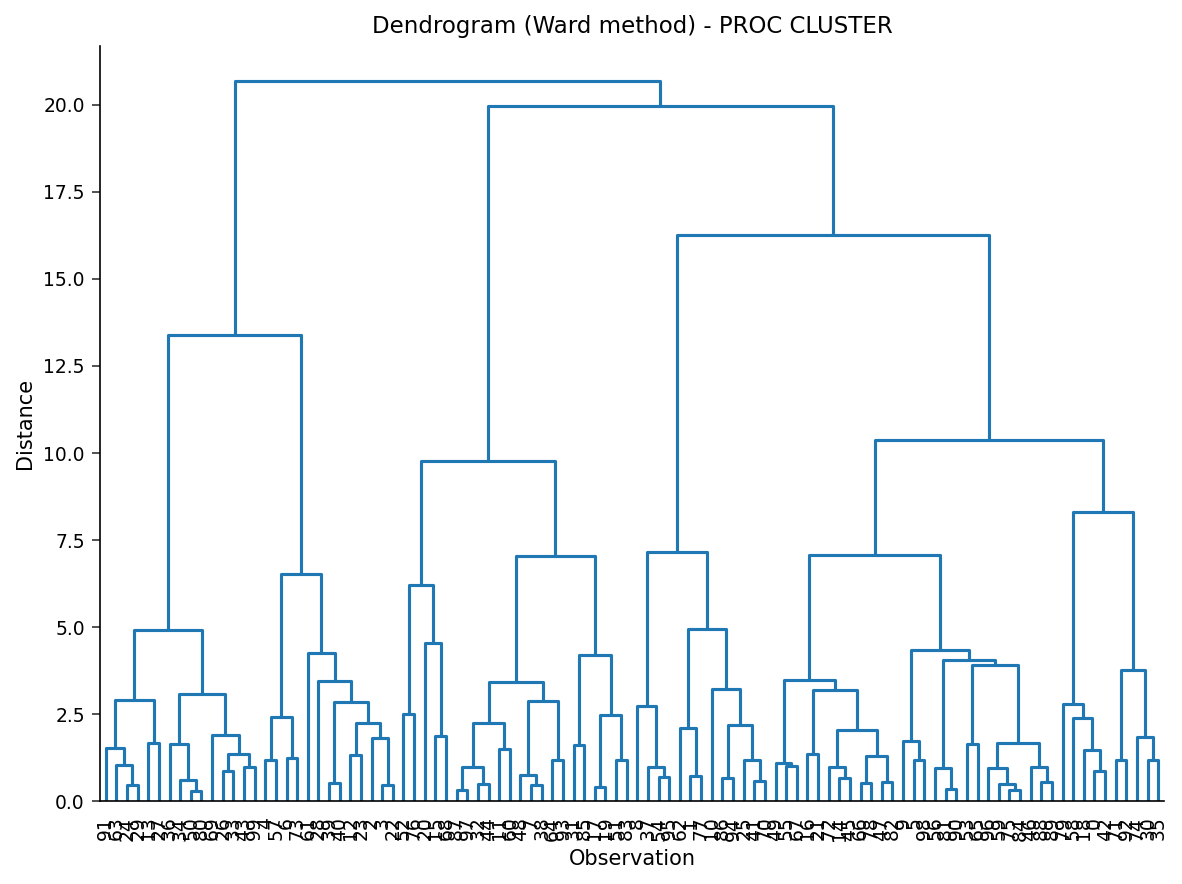

In [5]:
/* --------------------------------------------------------
   Feed factor scores into hierarchical clustering
   to detect defect patterns across shifts
   -------------------------------------------------------- */
proc cluster data=work.quality_factors
    method=ward
    outtree=work.quality_tree
    print=15;
    var factor1 factor2 factor3;
    id part_id;
run;

---

### Interpretation

The overall Kaiser-Meyer-Olkin measure of sampling adequacy is **0.85**, comfortably above the 0.50 floor, so the 12 metrics share enough common variance to justify factoring. The eigenvalues of the correlation matrix are **3.88, 3.60, and 3.48** for the first three factors and then collapse to **0.25 and below** — a textbook scree break that points unambiguously to a three-factor solution. Those three factors reproduce **91.3%** of the total variance (32.1% + 29.9% + 29.4%); the remaining nine factors together account for under 9%.

The factor pattern recovers the three measurement groups exactly:

- **Factor 1** loads on the four dimensional gauges — length, width, thickness, and bore diameter (loadings around 0.98 in magnitude) — and on nothing else.
- **Factor 2** loads on the four strength tests — tensile strength, hardness, yield point, and elongation (0.91 to 0.96).
- **Factor 3** loads on the four surface measures — surface roughness, coating thickness, gloss index, and defect count — with gloss carrying the opposite sign (0.95) from roughness and coating thickness (-0.94, -0.95), exactly as a "smoother surface = higher gloss" relationship implies.

Cross-loadings are negligible (all under 0.10), so the rotated structure is clean and each original metric maps to a single factor. Final communalities range from **0.82 (defect count) to 0.97 (length, width)**, meaning the three factors explain at least 82% of every individual metric.

Passing the three factor scores to Ward's hierarchical clustering produces the dendrogram above. Because the three latent dimensions were generated independently, the parts do not separate into tight, well-isolated groups — the largest merge distances grow smoothly rather than jumping at an obvious cut point — which is the expected outcome when no genuine sub-population structure exists. The dimensional-accuracy factor also shows no systematic shift-to-shift difference (boxplot above), consistent with a process that is in control across all three shifts. The practical takeaway: the 12-metric inspection panel can be monitored with just three orthogonal control variables without losing meaningful information.

---

In [6]:
/* --------------------------------------------------------
   Export quality factor scores with cluster assignments
   -------------------------------------------------------- */
proc export data=work.quality_factors
    outfile='quality_factor_scores.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.quality_factors outfile=quality_factor_scores.csv

NOTE: Exported 100 rows to quality_factor_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>